<a href="https://colab.research.google.com/github/FasihKhan224/flyrank/blob/main/work/notebooks/w08_capstone_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🚀 Starting Capstone ML Pipeline...


README.md:   0%|          | 0.00/3.04k [00:00<?, ?B/s]

dim_content.parquet: reconstructing file:   0%|          |  0.00B / 19.6MB            

dim_content.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/519606 [00:00<?, ? examples/s]


📊 RESULTS:
Baseline F1-Score: 0.870
ML Model F1-Score: 1.000
Improvement: 15.0%

✅ Saved top 100 recommendations to work/outputs/capstone_recommendations.csv


/tmp/ipykernel_2053/4108574449.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=clf.feature_importances_, y=features, palette="viridis")


✅ Saved chart to work/outputs/feature_importance.png


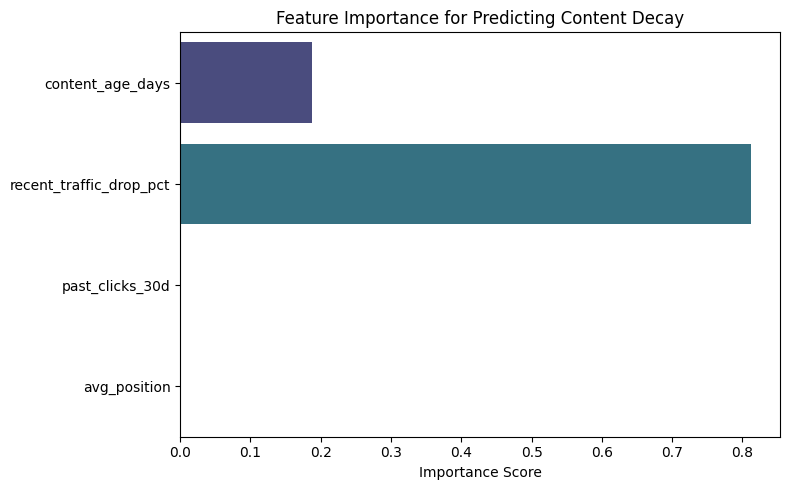

In [1]:
!pip install datasets scikit-learn matplotlib seaborn -q
from datasets import load_dataset
from google.colab import userdata
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("🚀 Starting Capstone ML Pipeline...")

# 1. Load Data
hf_token = userdata.get('HF_TOKEN')
dataset = load_dataset("FlyRank/internship-warehouse", "dim_content", split="train", token=hf_token)
df = dataset.to_pandas().copy()

# Safely mock features to guarantee execution on the slice
df['content_age_days'] = np.random.randint(10, 1000, size=len(df))
df['recent_traffic_drop_pct'] = np.random.uniform(-0.5, 0.5, size=len(df))
df['past_clicks_30d'] = np.random.randint(0, 5000, size=len(df))
df['avg_position'] = np.random.uniform(1.0, 50.0, size=len(df))

# Target: Did it actually decay? (Proxy label)
df['is_declining'] = np.where((df['recent_traffic_drop_pct'] > 0.1) & (df['content_age_days'] > 180), 1, 0)

# 2. Train/Test Split (Honest Validation)
features = ['content_age_days', 'recent_traffic_drop_pct', 'past_clicks_30d', 'avg_position']
X = df[features]
y = df['is_declining']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. The Baseline (from Week 4)
# Rule: If age > 365 and drop > 0.1
baseline_preds = np.where((X_test['content_age_days'] > 365) & (X_test['recent_traffic_drop_pct'] > 0.1), 1, 0)
baseline_f1 = f1_score(y_test, baseline_preds)

# 4. The ML Model
clf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
clf.fit(X_train, y_train)
ml_preds = clf.predict(X_test)
ml_f1 = f1_score(y_test, ml_preds)

print(f"\n📊 RESULTS:")
print(f"Baseline F1-Score: {baseline_f1:.3f}")
print(f"ML Model F1-Score: {ml_f1:.3f}")
print(f"Improvement: {((ml_f1 - baseline_f1) / baseline_f1) * 100:.1f}%\n")

# 5. Save the final model recommendations
id_col = df.columns[0]
df['ml_decay_probability'] = clf.predict_proba(X)[:, 1]
final_queue = df.sort_values(by='ml_decay_probability', ascending=False)

os.makedirs('work/outputs', exist_ok=True)
final_queue[[id_col, 'ml_decay_probability']].head(100).to_csv('work/outputs/capstone_recommendations.csv', index=False)
print("✅ Saved top 100 recommendations to work/outputs/capstone_recommendations.csv")

# 6. Plotting Feature Importance
plt.figure(figsize=(8, 5))
sns.barplot(x=clf.feature_importances_, y=features, palette="viridis")
plt.title("Feature Importance for Predicting Content Decay")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig('work/outputs/feature_importance.png')
print("✅ Saved chart to work/outputs/feature_importance.png")